# Статистика на Python

## Задание №1

Загрузить данные из файла "insurance.csv".

In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sts


df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Задание №2

С помощью метода describe() посмотреть статистику по данным. Сделать
выводы.

In [127]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Задание №3

Построить гистограммы для числовых показателей. Сделать выводы.

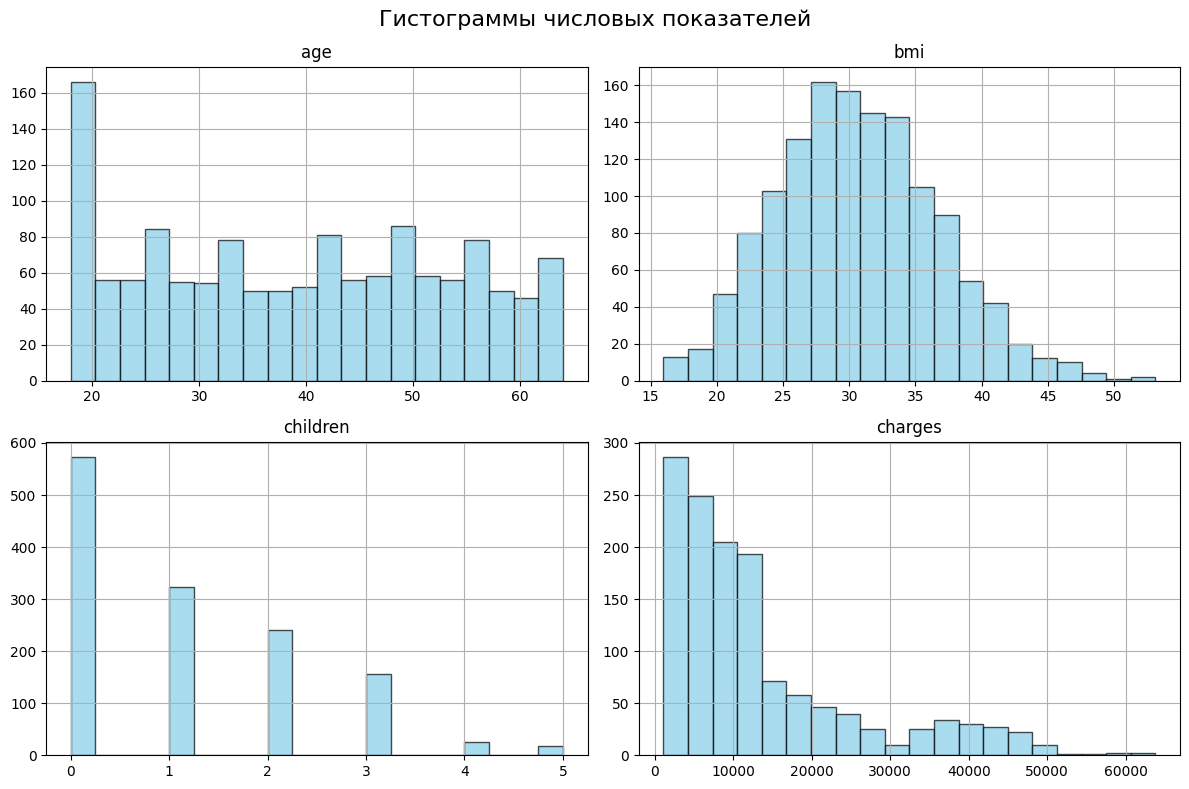

In [128]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_columns].hist(figsize=(12, 8), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.suptitle('Гистограммы числовых показателей', fontsize=16)
plt.tight_layout()
plt.show()

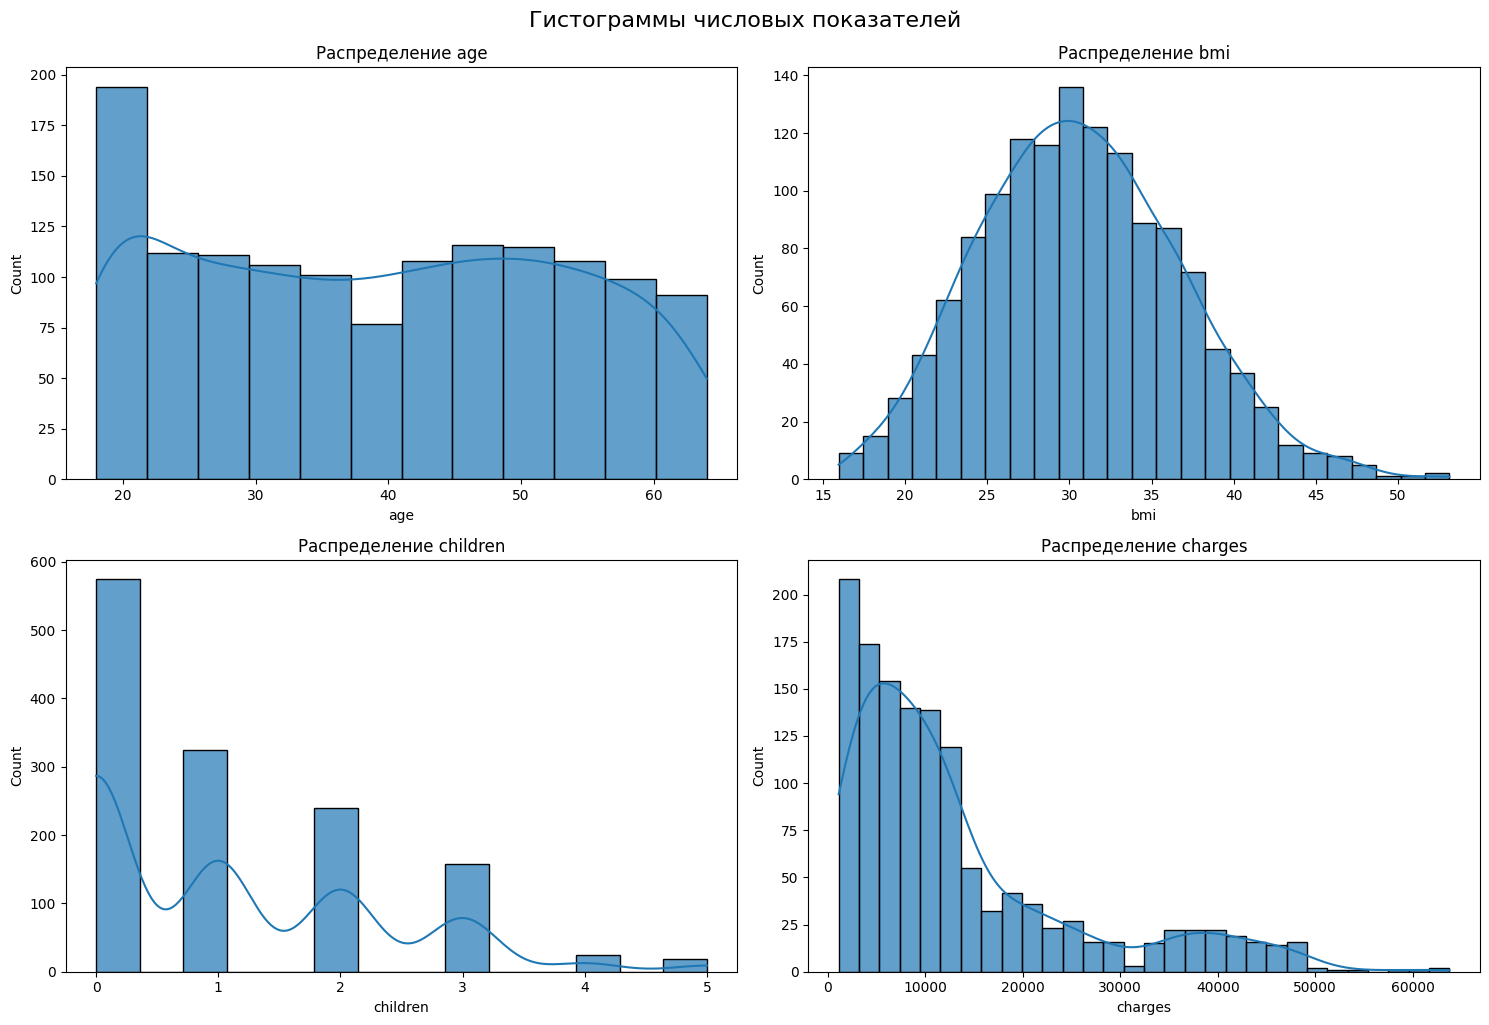

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, ax=axes[i], kde=True, alpha=0.7)
    axes[i].set_title(f'Распределение {column}')

plt.tight_layout()
plt.suptitle('Гистограммы числовых показателей', fontsize=16, y=1.02)
plt.show()

## Задание №4

Найти меры центральной тенденции и меры разброса для индекса массы
тела (bmi) и расходов (charges). Отобразить результаты в виде текста и на
гистограммах (3 вертикальные линии). Добавить легенду на графики.
Сделать выводы.


In [130]:
# Меры центральной тенденции
bmi_mean = df['bmi'].mean()
bmi_median = df["bmi"].median()
bmi_mode = df['bmi'].mode()[0]

charges_mean = df['charges'].mean()
charges_median = df['charges'].median()
charges_mode = df['charges'].mode()[0]

# Меры изменчивости
bmi_std = df['bmi'].std()
bmi_range = df['bmi'].max() - df['bmi'].min()
bmi_q1 = df['bmi'].quantile(0.25)
bmi_q3 = df['bmi'].quantile(0.75)
bmi_iqr = bmi_q3 - bmi_q1

charges_std = df['charges'].std()
charges_range = df['charges'].max() - df['charges'].min()
charges_q1 = df['charges'].quantile(0.25)
charges_q3 = df['charges'].quantile(0.75)
charges_iqr = charges_q3 - charges_q1

print("=" * 60)
print("МЕРЫ ЦЕНТРАЛЬНОЙ ТЕНДЕНЦИИ И РАЗБРОСА ДЛЯ BMI")
print("=" * 60)
print(f"Среднее значение: {bmi_mean:.2f}")
print(f"Медиана: {bmi_median:.2f}")
print(f"Мода: {bmi_mode:.2f}")
print(f"Стандартное отклонение: {bmi_std:.2f}")
print(f"Размах: {bmi_range:.2f}")
print(f"Межквартильный размах (IQR): {bmi_iqr:.2f}")
print(f"Q1 (25-й процентиль): {bmi_q1:.2f}")
print(f"Q3 (75-й процентиль): {bmi_q3:.2f}")

print("\n" + "=" * 60)
print("МЕРЫ ЦЕНТРАЛЬНОЙ ТЕНДЕНЦИИ И РАЗБРОСА ДЛЯ Charges")
print("=" * 60)
print(f"Среднее значение: {charges_mean:.2f}")
print(f"Медиана: {charges_median:.2f}")
print(f"Мода: {charges_mode:.2f}")
print(f"Стандартное отклонение: {charges_std:.2f}")
print(f"Размах: {charges_range:.2f}")
print(f"Межквартильный размах (IQR): {charges_iqr:.2f}")
print(f"Q1 (25-й процентиль): {charges_q1:.2f}")
print(f"Q3 (75-й процентиль): {charges_q3:.2f}")

МЕРЫ ЦЕНТРАЛЬНОЙ ТЕНДЕНЦИИ И РАЗБРОСА ДЛЯ BMI
Среднее значение: 30.66
Медиана: 30.40
Мода: 32.30
Стандартное отклонение: 6.10
Размах: 37.17
Межквартильный размах (IQR): 8.40
Q1 (25-й процентиль): 26.30
Q3 (75-й процентиль): 34.69

МЕРЫ ЦЕНТРАЛЬНОЙ ТЕНДЕНЦИИ И РАЗБРОСА ДЛЯ Charges
Среднее значение: 13270.42
Медиана: 9382.03
Мода: 1639.56
Стандартное отклонение: 12110.01
Размах: 62648.55
Межквартильный размах (IQR): 11899.63
Q1 (25-й процентиль): 4740.29
Q3 (75-й процентиль): 16639.91


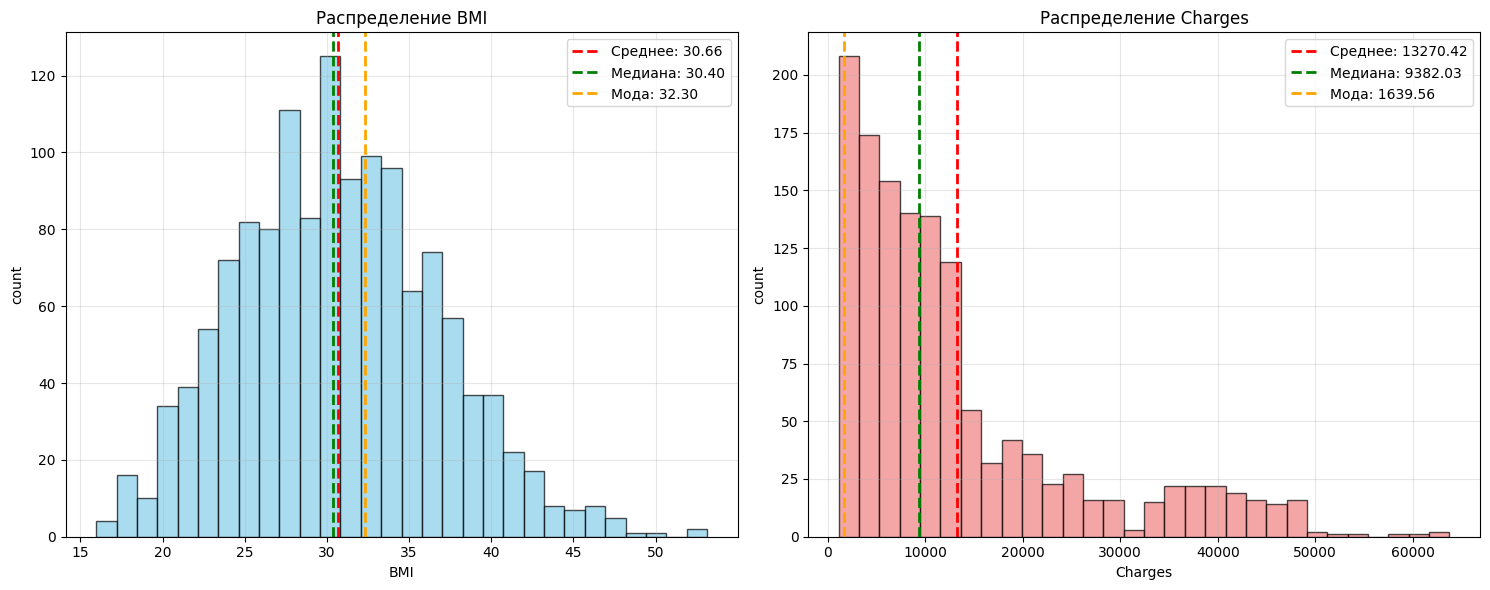

In [131]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(df['bmi'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(bmi_mean, color='red', linestyle='--', linewidth=2, label=f'Среднее: {bmi_mean:.2f}')
ax1.axvline(bmi_median, color='green', linestyle='--', linewidth=2, label=f'Медиана: {bmi_median:.2f}')
ax1.axvline(bmi_mode, color='orange', linestyle='--', linewidth=2, label=f'Мода: {bmi_mode:.2f}')
ax1.set_title('Распределение BMI')
ax1.set_xlabel('BMI')
ax1.set_ylabel('count')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(df['charges'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
ax2.axvline(charges_mean, color='red', linestyle='--', linewidth=2, label=f'Среднее: {charges_mean:.2f}')
ax2.axvline(charges_median, color='green', linestyle='--', linewidth=2, label=f'Медиана: {charges_median:.2f}')
ax2.axvline(charges_mode, color='orange', linestyle='--', linewidth=2, label=f'Мода: {charges_mode:.2f}')
ax2.set_title('Распределение Charges')
ax2.set_xlabel('Charges')
ax2.set_ylabel('count')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание №5

Построить box-plot для числовых показателей. Названия графиков должны
соответствовать названиям признаков. Сделать выводы.

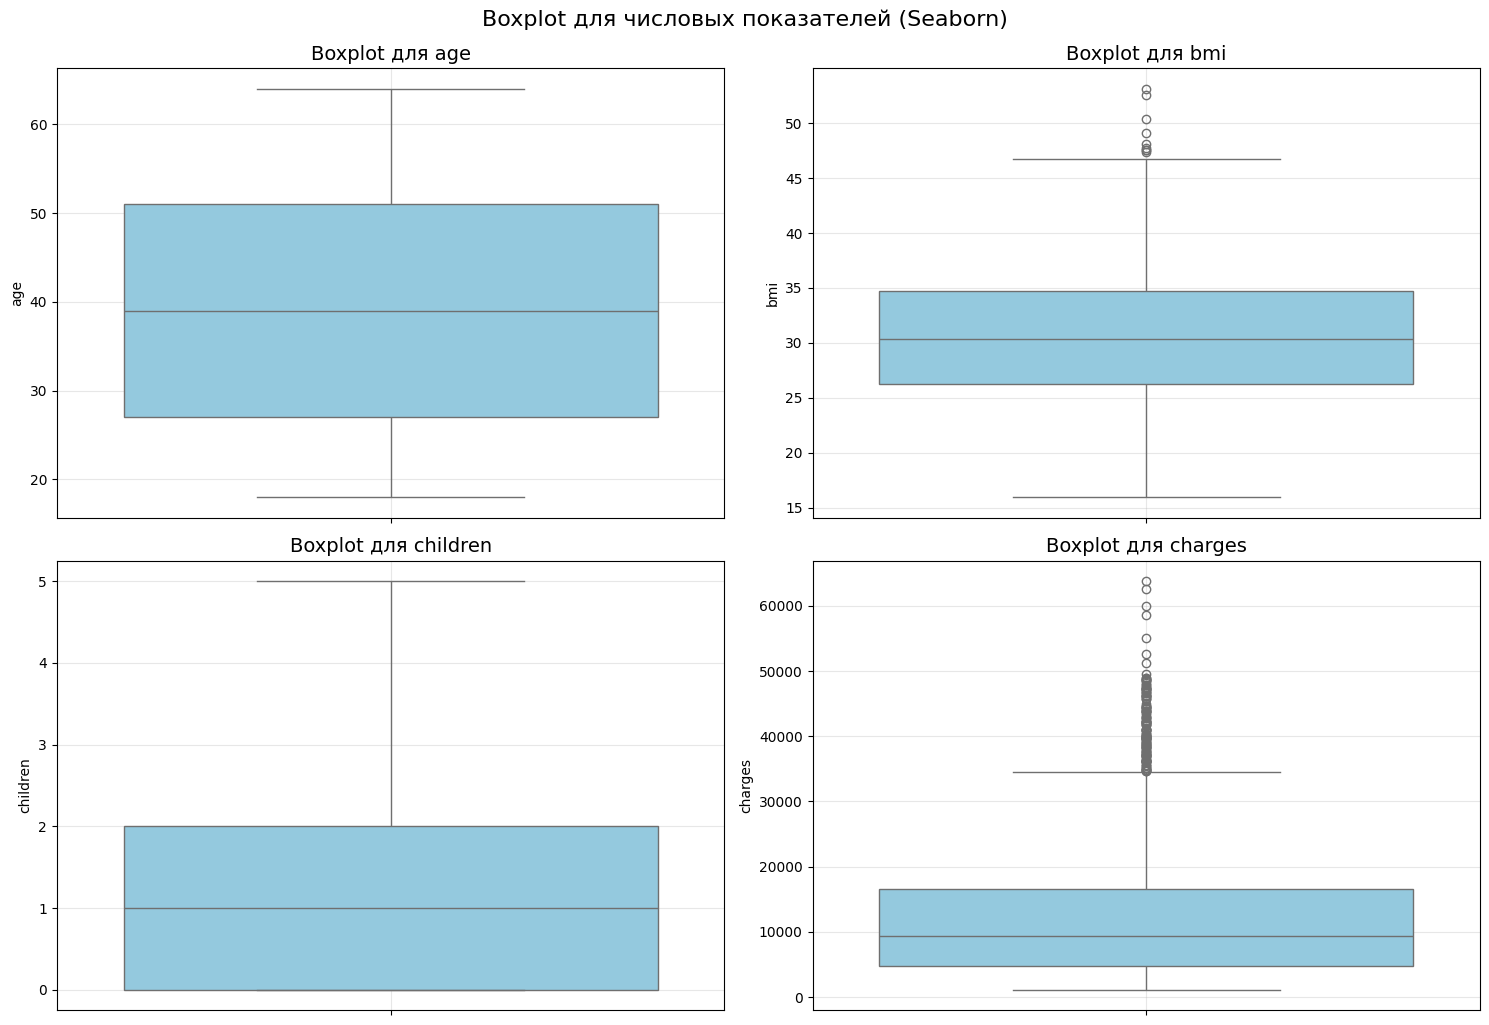

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=df[column], ax=axes[i], color="skyblue")
    axes[i].set_title(f'Boxplot для {column}', fontsize=14)
    axes[i].set_ylabel(column)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Boxplot для числовых показателей (Seaborn)', fontsize=16, y=1.02)
plt.show()

## Задание №6

Используя признак charges или imb, проверить, выполняется ли
центральная предельная теорема. Использовать различные длины выборок
n. Количество выборок = 300. Вывести результат в виде гистограмм. Найти
стандартное отклонение и среднее для полученных распределений.
Сделать выводы.

Параметры генеральной совокупности:
Среднее генеральной совокупности: 30.6634
Стандартное отклонение генеральной совокупности: 6.0982
Размер генеральной совокупности: 1338



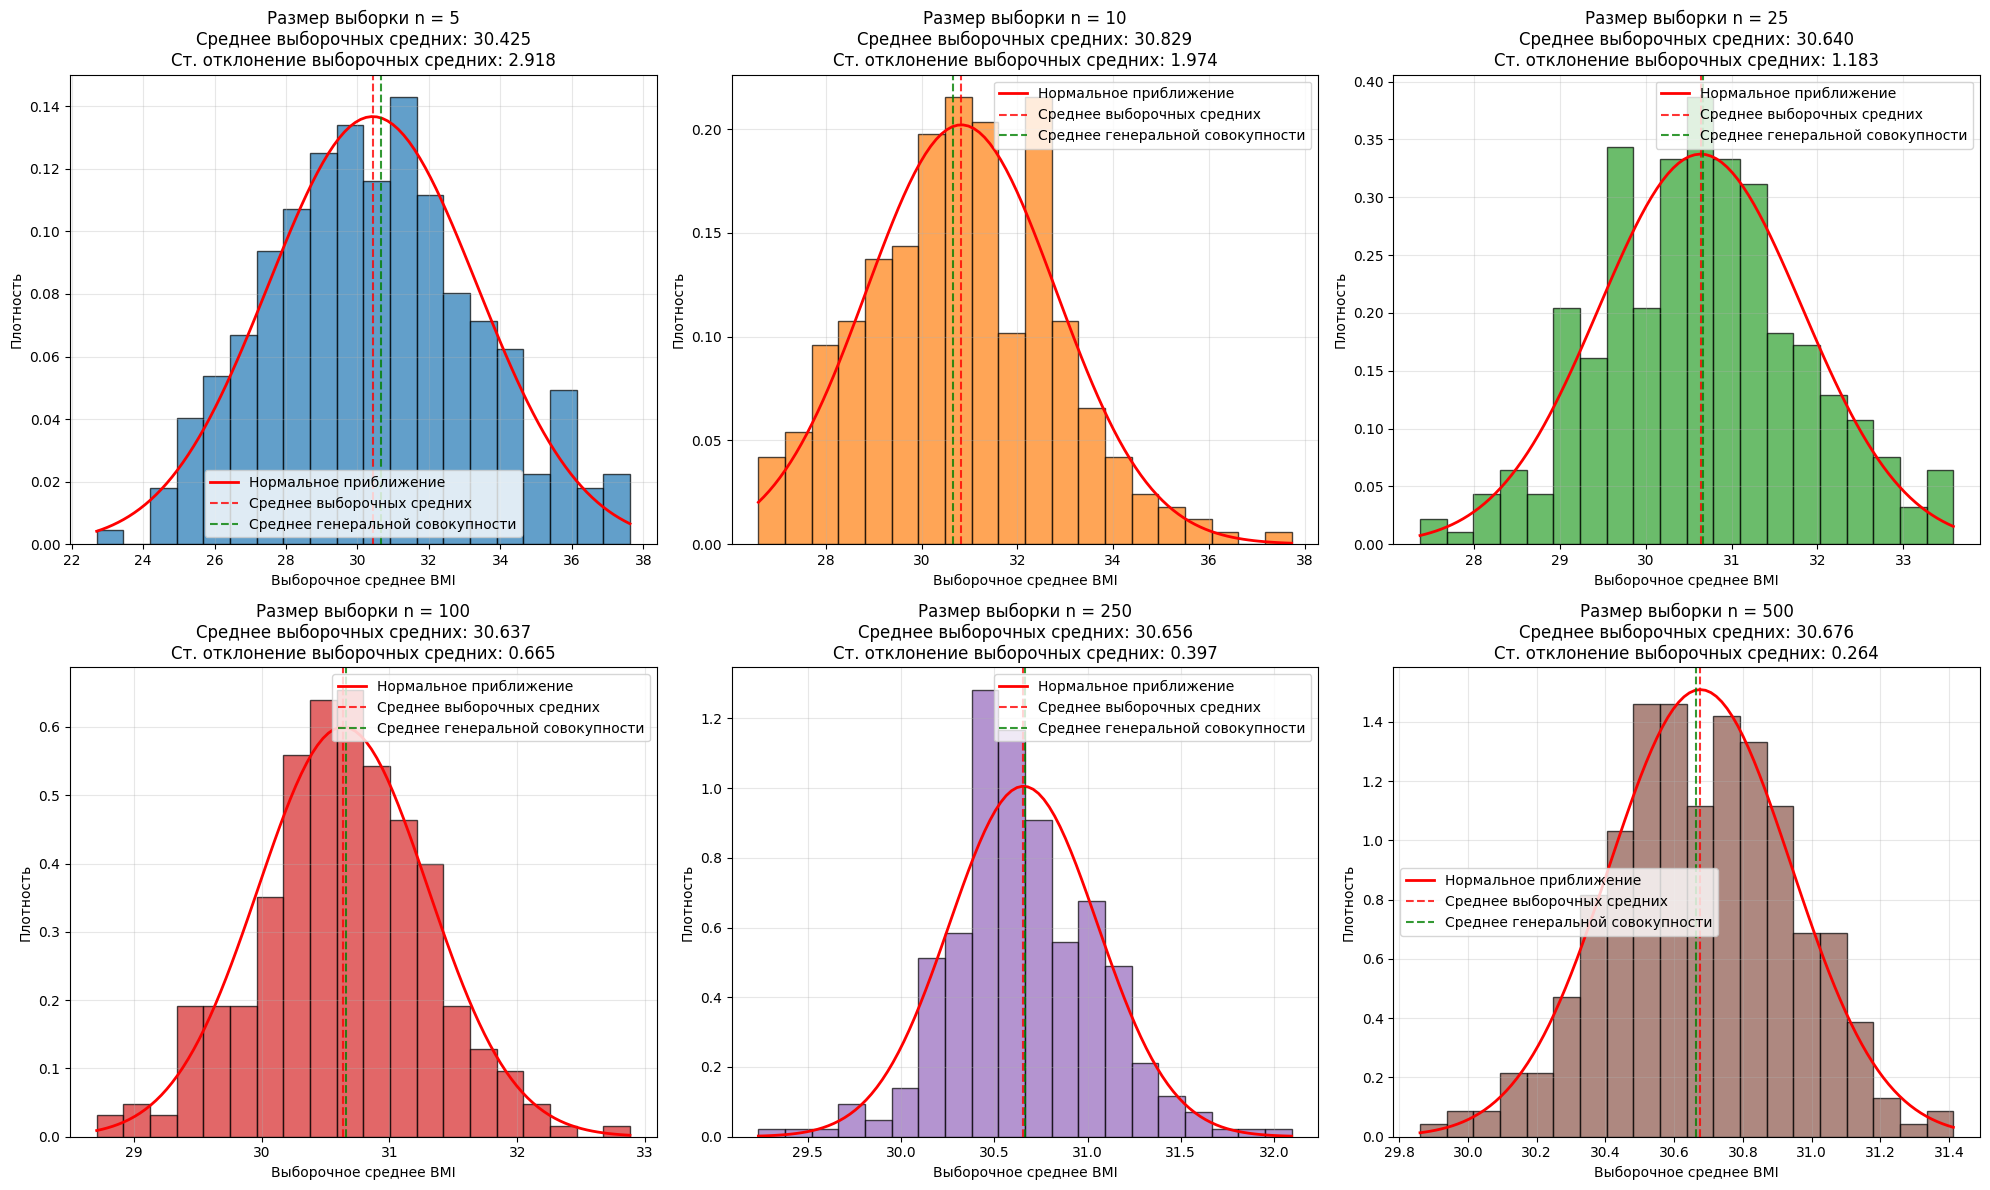

In [133]:
sample_sizes = [5, 10, 25, 100, 250, 500]
num_samples = 300

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

population_mean = df['bmi'].mean()
population_std = df['bmi'].std()

print(f"Параметры генеральной совокупности:")
print(f"Среднее генеральной совокупности: {population_mean:.4f}")
print(f"Стандартное отклонение генеральной совокупности: {population_std:.4f}")
print(f"Размер генеральной совокупности: {len(df)}", end = "\n\n")

for i, n in enumerate(sample_sizes):
    sample_means = []
    
    for _ in range(num_samples):
        sample = df['bmi'].sample(n, replace=True)
        sample_means.append(sample.mean())
    
    sample_means = np.array(sample_means)
    
    means_of_means = sample_means.mean()
    std_of_means = sample_means.std()
    
    axes[i].hist(sample_means, bins=20, alpha=0.7, color=f'C{i}', edgecolor='black', density=True)
    
    x = np.linspace(sample_means.min(), sample_means.max(), 100)
    y = sts.norm.pdf(x, means_of_means, std_of_means)

    axes[i].plot(x, y, 'r-', linewidth=2, label='Нормальное приближение')
    
    axes[i].axvline(means_of_means, color='red', linestyle='--', alpha=0.8, label=f'Среднее выборочных средних')
    axes[i].axvline(population_mean, color='green', linestyle='--', alpha=0.8, label=f'Среднее генеральной совокупности')
    
    axes[i].set_title(f'Размер выборки n = {n}\n'
                        f'Среднее выборочных средних: {means_of_means:.3f}\n'
                        f'Ст. отклонение выборочных средних: {std_of_means:.3f}', 
                        fontsize=12)
    axes[i].set_xlabel('Выборочное среднее BMI')
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание №7

Построить 95% и 99% доверительный интервал для среднего значения
расходов и среднего значения индекса массы тела.

{0.95: {'lower': np.float64(30.336642971534822), 'upper': np.float64(30.990150750438275), 'margin': np.float64(0.3267538894517263), 'z_value': np.float64(1.959963984540054)}, 0.99: {'lower': np.float64(30.233969458168303), 'upper': np.float64(31.092824263804793), 'margin': np.float64(0.4294274028182451), 'z_value': np.float64(2.5758293035489004)}}
{0.95: {'lower': np.float64(12621.54197822916), 'upper': np.float64(13919.302552053354), 'margin': np.float64(648.8802869120973), 'z_value': np.float64(1.959963984540054)}, 0.99: {'lower': np.float64(12417.649014863586), 'upper': np.float64(14123.195515418927), 'margin': np.float64(852.7732502776717), 'z_value': np.float64(2.5758293035489004)}}


(12.27721990219421, 14.263624628088303)

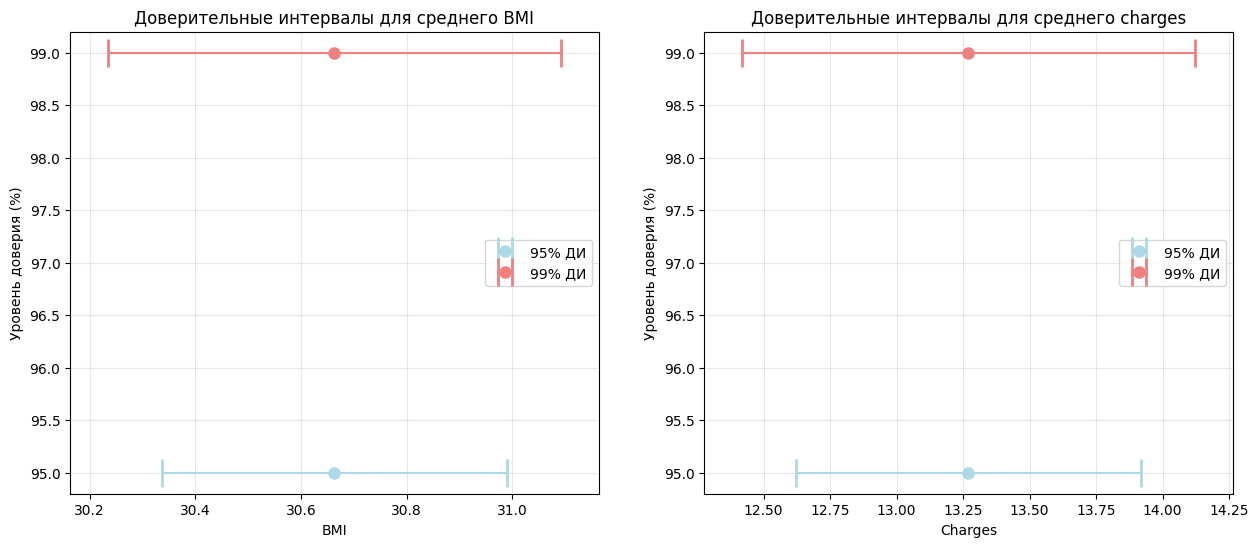

In [134]:
def calculate_confidence_intervals(data, confidence_levels=[0.95, 0.99]):
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)
    
    intervals = {}
    for cl in confidence_levels:
        z_value = sts.norm.ppf(1 - (1 - cl) / 2)
        
        margin = z_value * se
        
        lower = mean - margin
        upper = mean + margin
        
        intervals[cl] = {
            'lower': lower,
            'upper': upper,
            'margin': margin,
            'z_value': z_value
        }
    
    return mean, std, se, intervals


bmi_mean, bmi_std, bmi_se, bmi_intervals = calculate_confidence_intervals(df['bmi'])
print(bmi_intervals)

charges_mean, charges_std, charges_se, charges_intervals = calculate_confidence_intervals(df['charges'])
print(charges_intervals)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['lightblue', 'lightcoral']

for i, (cl, interval) in enumerate(bmi_intervals.items()):
    ax1.errorbar(bmi_mean, int(cl*100), 
                xerr=interval['margin'], 
                fmt='o', 
                color=colors[i],
                capsize=10,
                capthick=2,
                markersize=8,
                label=f'{int(cl*100)}% ДИ')
    
ax1.set_xlabel('BMI')
ax1.set_ylabel('Уровень доверия (%)')
ax1.set_title('Доверительные интервалы для среднего BMI')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(bmi_mean - 3*bmi_se, bmi_mean + 3*bmi_se)

for i, (cl, interval) in enumerate(charges_intervals.items()):
    ax2.errorbar(charges_mean/1000, int(cl*100), 
                xerr=interval['margin']/1000, 
                fmt='o', 
                color=colors[i],
                capsize=10,
                capthick=2,
                markersize=8,
                label=f'{int(cl*100)}% ДИ')
    
ax2.set_xlabel('Charges')
ax2.set_ylabel('Уровень доверия (%)')
ax2.set_title('Доверительные интервалы для среднего charges')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(charges_mean/1000 - 3*charges_se/1000, charges_mean/1000 + 3*charges_se/1000)

## Задание №8

Проверить распределения следующих признаков на нормальность: индекс
массы тела, расходы. Сформулировать нулевую и альтернативную
гипотезы. Для каждого признака использовать KS-тест и q-q plot. Сделать
выводы на основе полученных p-значений.

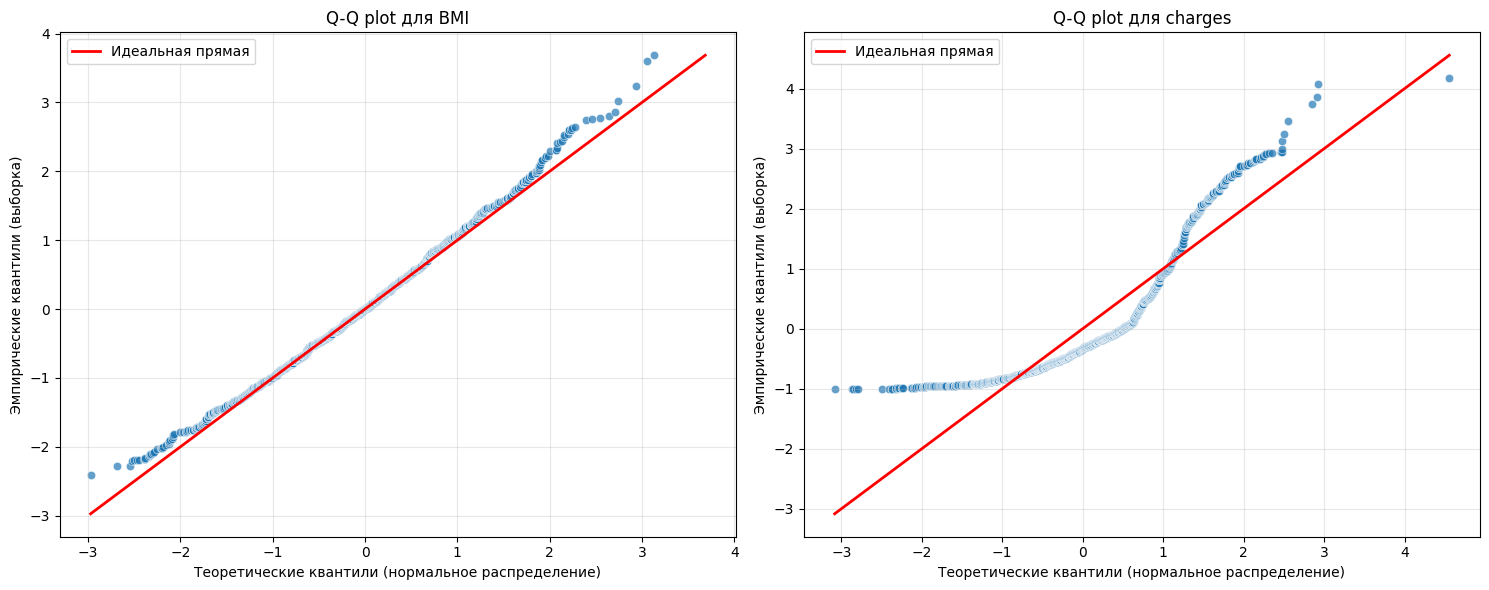

In [135]:
def create_qq_plot_seaborn(data, ax, title):
    """Создание Q-Q plot с использованием seaborn как в методичке"""
    
    standardized_data = (data - np.mean(data)) / np.std(data)
    
    theoretical_quantiles = np.sort(sts.norm.rvs(size=len(data)))
    
    empirical_quantiles = np.sort(standardized_data)
    
    sns.scatterplot(x=theoretical_quantiles, y=empirical_quantiles, ax=ax, alpha=0.7)
    
    min_val = min(theoretical_quantiles.min(), empirical_quantiles.min())
    max_val = max(theoretical_quantiles.max(), empirical_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r-', linewidth=2, label='Идеальная прямая')
    
    ax.set_xlabel('Теоретические квантили (нормальное распределение)')
    ax.set_ylabel('Эмпирические квантили (выборка)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return theoretical_quantiles, empirical_quantiles


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

theoretical_bmi, empirical_bmi = create_qq_plot_seaborn(
    df['bmi'], axes[0], 'Q-Q plot для BMI'
)

theoretical_charges, empirical_charges = create_qq_plot_seaborn(
    df['charges'], axes[1], 'Q-Q plot для charges'
)

plt.tight_layout()
plt.show()

Строим Q-Q plot для расходов...


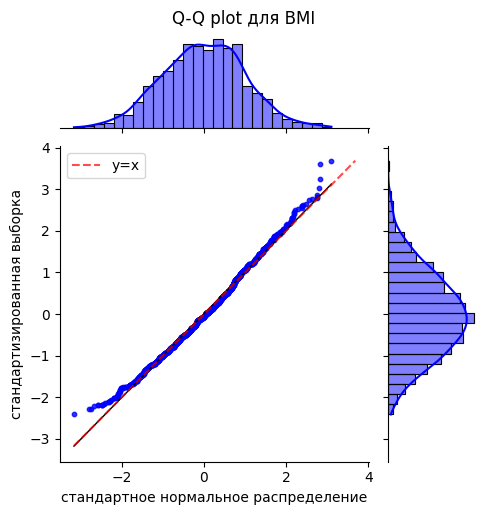

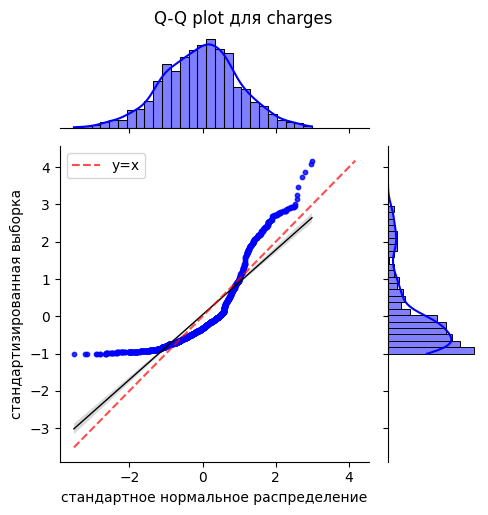

In [136]:
def create_qq_jointplot(data, title):
    standardized_data = (data - np.mean(data)) / np.std(data)
    
    theoretical_quantiles = np.sort(sts.norm.rvs(size=len(data)))
    
    empirical_quantiles = np.sort(standardized_data)
    
    qq_data = pd.DataFrame({
        'theoretical': theoretical_quantiles,
        'empirical': empirical_quantiles
    })
    
    g = sns.jointplot(
        x='theoretical', 
        y='empirical',
        data=qq_data,
        kind="reg", 
        truncate=True,
        color="b", 
        height=5,
        ratio=3,
        scatter_kws={"s": 10}, 
        line_kws={"lw": 1, 'color':'black'}
    )
    
    min_val = min(theoretical_quantiles.min(), empirical_quantiles.min())
    max_val = max(theoretical_quantiles.max(), empirical_quantiles.max())
    g.ax_joint.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='y=x')
    g.ax_joint.legend()
    
    g.figure.suptitle(title, y=1.02)
    
    g.set_axis_labels(
        'стандартное нормальное распределение', 
        'стандартизированная выборка'
    )
    
    return g


g_bmi = create_qq_jointplot(
    df['bmi'], 
    'Q-Q plot для BMI'
)

print("Строим Q-Q plot для расходов...")
g_charges = create_qq_jointplot(
    df['charges'], 
    'Q-Q plot для charges'
)

plt.show()

Статистика KS-теста: 0.026140
p-value: 0.314540
Уровень значимости: α = 0.05

НЕ ОТВЕРГАЕМ нулевую гипотезу H0
ВЫВОД: Распределение BMI НЕ ОТЛИЧАЕТСЯ от нормального

Статистика KS-теста: 0.188462
p-value: 0.000000
Уровень значимости: α = 0.05

ОТВЕРГАЕМ нулевую гипотезу H0
ВЫВОД: Распределение charges ОТЛИЧАЕТСЯ от нормального


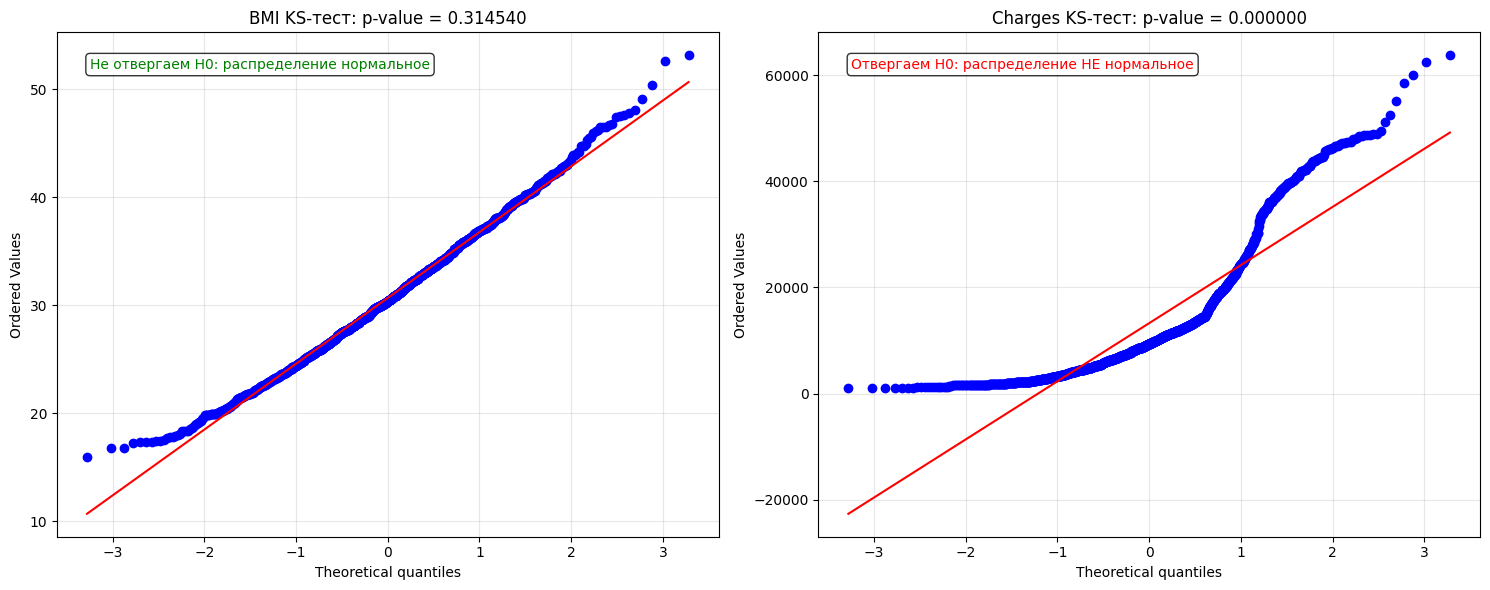

In [137]:
def perform_ks_test(data, feature_name, ax):
    standardized_data = (data - np.mean(data)) / np.std(data)
    
    ks_statistic, ks_pvalue = sts.kstest(standardized_data, 'norm')
    
    sts.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'{feature_name} KS-тест: p-value = {ks_pvalue:.6f}')
    ax.grid(True, alpha=0.3)
    
    if ks_pvalue < 0.05:
        result_text = "Отвергаем H0: распределение НЕ нормальное"
        color = 'red'
    else:
        result_text = "Не отвергаем H0: распределение нормальное"  
        color = 'green'
    
    ax.text(0.05, 0.95, result_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', color=color,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    return ks_statistic, ks_pvalue, standardized_data


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ks_stat_bmi, ks_pvalue_bmi, bmi_standardized = perform_ks_test(df['bmi'], 'BMI', ax1)

print(f"Статистика KS-теста: {ks_stat_bmi:.6f}")
print(f"p-value: {ks_pvalue_bmi:.6f}")
print(f"Уровень значимости: α = 0.05", end = "\n\n")

if ks_pvalue_bmi < 0.05:
    print("ОТВЕРГАЕМ нулевую гипотезу H0")
    print("ВЫВОД: Распределение BMI ОТЛИЧАЕТСЯ от нормального", end = "\n\n")
else:
    print("НЕ ОТВЕРГАЕМ нулевую гипотезу H0") 
    print("ВЫВОД: Распределение BMI НЕ ОТЛИЧАЕТСЯ от нормального", end = "\n\n")

ks_stat_charges, ks_pvalue_charges, charges_standardized = perform_ks_test(df['charges'], 'Charges', ax2)
print(f"Статистика KS-теста: {ks_stat_charges:.6f}")
print(f"p-value: {ks_pvalue_charges:.6f}")
print(f"Уровень значимости: α = 0.05", end = "\n\n")

if ks_pvalue_charges < 0.05:
    print("ОТВЕРГАЕМ нулевую гипотезу H0")
    print("ВЫВОД: Распределение charges ОТЛИЧАЕТСЯ от нормального")
else:
    print("НЕ ОТВЕРГАЕМ нулевую гипотезу H0")
    print("ВЫВОД: Распределение charges НЕ ОТЛИЧАЕТСЯ от нормального")

plt.tight_layout()
plt.show()

## Задание №9

Загрузить данные из файла "ECDCCases.cs".

In [138]:
frame = pd.read_csv("ECDCCases.csv")
frame.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,14/12/2020,14,12,2020,746,6,Afghanistan,AF,AFG,38041757.0,Asia,9.013779
1,13/12/2020,13,12,2020,298,9,Afghanistan,AF,AFG,38041757.0,Asia,7.052776
2,12/12/2020,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
3,12/12/2020,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
4,11/12/2020,11,12,2020,63,10,Afghanistan,AF,AFG,38041757.0,Asia,7.134266


## Задание №10

Проверить в данных наличие пропущенных значений. Вывести
количество пропущенных значений в процентах. Удалить два признака, в
которых больше всех пропущенных значений. Для оставшихся признаков
обработать пропуски: для категориального признака использовать
заполнение значением по умолчанию (например, «other»), для числового
признака использовать заполнение медианным значением. Показать, что
пропусков больше в данных нет.

### Количество пропущенных значений по убыванию

In [139]:
null_series = frame.isnull().sum().sort_values(ascending=False)
print(null_series)

Cumulative_number_for_14_days_of_COVID-19_cases_per_100000    2879
geoId                                                          275
popData2019                                                    123
countryterritoryCode                                           123
year                                                             0
month                                                            0
day                                                              0
dateRep                                                          0
countriesAndTerritories                                          0
deaths                                                           0
cases                                                            0
continentExp                                                     0
dtype: int64


### Количество пропущенных значений в процентах

In [140]:
for column in frame.columns:
    missing = np.mean(frame[column].isna() * 100)
    print(f"{column}: {round(missing, 2)}%")

dateRep: 0.0%
day: 0.0%
month: 0.0%
year: 0.0%
cases: 0.0%
deaths: 0.0%
countriesAndTerritories: 0.0%
geoId: 0.44%
countryterritoryCode: 0.2%
popData2019: 0.2%
continentExp: 0.0%
Cumulative_number_for_14_days_of_COVID-19_cases_per_100000: 4.65%


### Удаление признаков с наибольшим количеством пропущенных значений

In [141]:
N = 2
frame = frame.drop(columns=null_series.head(N).index, errors='ignore')
frame.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,countryterritoryCode,popData2019,continentExp
0,14/12/2020,14,12,2020,746,6,Afghanistan,AFG,38041757.0,Asia
1,13/12/2020,13,12,2020,298,9,Afghanistan,AFG,38041757.0,Asia
2,12/12/2020,12,12,2020,113,11,Afghanistan,AFG,38041757.0,Asia
3,12/12/2020,12,12,2020,113,11,Afghanistan,AFG,38041757.0,Asia
4,11/12/2020,11,12,2020,63,10,Afghanistan,AFG,38041757.0,Asia


In [142]:
frame.fillna({"popData2019": frame["popData2019"].median()}, inplace=True)
null_series = frame.isnull().sum().sort_values(ascending=False)
print(null_series)

countryterritoryCode       123
dateRep                      0
day                          0
month                        0
cases                        0
year                         0
deaths                       0
countriesAndTerritories      0
popData2019                  0
continentExp                 0
dtype: int64


In [143]:
frame.fillna("other", inplace=True)
null_series = frame.isnull().sum().sort_values(ascending=False)
print(null_series)

dateRep                    0
day                        0
month                      0
year                       0
cases                      0
deaths                     0
countriesAndTerritories    0
countryterritoryCode       0
popData2019                0
continentExp               0
dtype: int64


## Задание №11

Посмотреть статистику по данным, используя describe(). Сделать выводы
о том, какие признаки содержат выбросы. Посмотреть, для каких стран
количество смертей в день превысило 3000 и сколько таких дней было.

In [144]:
frame.describe()

,day,month,year,cases,deaths,popData2019
count,61904.000000,61904.000000,61904.000000,61904.000000,61904.000000,6.190400e+04
mean,15.629232,7.067104,2019.998918,1155.079026,26.053987,4.091909e+07
std,8.841624,2.954816,0.032881,6779.010824,131.222948,1.529798e+08
min,1.000000,1.000000,2019.000000,-8261.000000,-1918.000000,8.150000e+02
25%,8.000000,5.000000,2020.000000,0.000000,0.000000,1.324820e+06
50%,15.000000,7.000000,2020.000000,15.000000,0.000000,7.169456e+06
75%,23.000000,10.000000,2020.000000,273.000000,4.000000,2.851583e+07
max,31.000000,12.000000,2020.000000,234633.000000,4928.000000,1.433784e+09


In [145]:
frame[frame["deaths"] > 3000]

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,countryterritoryCode,popData2019,continentExp
2118,02/10/2020,2,10,2020,14001,3351,Argentina,ARG,44780675.0,America
16908,07/09/2020,7,9,2020,-8261,3800,Ecuador,ECU,17373657.0,America
37038,09/10/2020,9,10,2020,4936,3013,Mexico,MEX,127575529.0,America
44888,14/08/2020,14,8,2020,9441,3935,Peru,PER,32510462.0,America
44909,24/07/2020,24,7,2020,4546,3887,Peru,PER,32510462.0,America
59007,12/12/2020,12,12,2020,234633,3343,United_States_of_America,USA,329064917.0,America
59009,10/12/2020,10,12,2020,220025,3124,United_States_of_America,USA,329064917.0,America
59016,03/12/2020,3,12,2020,203311,3190,United_States_of_America,USA,329064917.0,America
59239,24/04/2020,24,4,2020,26543,3179,United_States_of_America,USA,329064917.0,America
59245,18/04/2020,18,4,2020,30833,3770,United_States_of_America,USA,329064917.0,America


In [146]:
print(len(frame[frame["deaths"] > 3000]))

11


## Задание №12

Найти дублирование данных. Удалить дубликаты.

In [147]:
subset = ["dateRep", "cases", "deaths", "countriesAndTerritories", "countryterritoryCode", "popData2019"]
duplicated = frame[frame.duplicated(subset, keep=False)]
duplicated

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,countryterritoryCode,popData2019,continentExp
2,12/12/2020,12,12,2020,113,11,Afghanistan,AFG,38041757.0,Asia
3,12/12/2020,12,12,2020,113,11,Afghanistan,AFG,38041757.0,Asia
217,12/05/2020,12,5,2020,285,2,Afghanistan,AFG,38041757.0,Asia
218,12/05/2020,12,5,2020,285,2,Afghanistan,AFG,38041757.0,Asia
48009,29/05/2020,29,5,2020,0,0,Saint_Lucia,LCA,182795.0,America
48010,29/05/2020,29,5,2020,0,0,Saint_Lucia,LCA,182795.0,America
48072,28/03/2020,28,3,2020,0,0,Saint_Lucia,LCA,182795.0,America
48073,28/03/2020,28,3,2020,0,0,Saint_Lucia,LCA,182795.0,America


In [148]:
frame.drop_duplicates(subset, ignore_index=True, inplace=True)

In [149]:
duplicated = frame[frame.duplicated(subset, keep=False)]
duplicated

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,countryterritoryCode,popData2019,continentExp


## Задание №13

Загрузить данные из файла "bmi.csv". Взять оттуда две выборки. Одна
выборка – это индекс массы тела людей c региона northwest, вторая
выборка – это индекс массы тела людей с региона southwest. Сравнить
средние значения этих выборок, используя t-критерий Стьюдента.
Предварительно проверить выборки на нормальность (критерий ШопироУилка) и на гомогенность дисперсии (критерий Бартлетта).

In [150]:
bmi_frame = pd.read_csv("bmi.csv")
print(bmi_frame.shape)
bmi_frame.head()

(1338, 2)


,bmi,region
0,27.900,southwest
1,33.770,southeast
2,33.000,southeast
3,22.705,northwest
4,28.880,northwest


In [151]:
northwest = bmi_frame[bmi_frame["region"] == "northwest"]
northwest.shape

(325, 2)

In [152]:
southwest = bmi_frame[bmi_frame["region"] == "southwest"]
southwest.shape

(325, 2)

### Проверка выборок на нормальность: критерий Шопиро-Уилка

In [153]:
shapiro_northwest = sts.shapiro(northwest["bmi"].values)
shapiro_southwest = sts.shapiro(southwest["bmi"].values)

print("Результаты теста Шапиро-Уилка для northwest:")
print(f"Статистика: {shapiro_northwest.statistic:.5f}, p-value: {shapiro_northwest.pvalue:.5f}")

print("\nРезультаты теста Шапиро-Уилка для southwest:")
print(f"Статистика: {shapiro_southwest.statistic:.5f}, p-value: {shapiro_southwest.pvalue:.5f}", end = "\n\n")

alpha = 0.05
if shapiro_northwest.pvalue > alpha:
    print("Выборка northwest имеет нормальное распределение")
else:
    print("Выборка northwest не имеет нормального распределения")

if shapiro_southwest.pvalue > alpha:
    print("Выборка southwest имеет нормальное распределение")
else:
    print("Выборка southwest не имеет нормального распределения")

Результаты теста Шапиро-Уилка для northwest:
Статистика: 0.99546, p-value: 0.46559

Результаты теста Шапиро-Уилка для southwest:
Статистика: 0.99493, p-value: 0.36296

Выборка northwest имеет нормальное распределение
Выборка southwest имеет нормальное распределение


###  Проверка выборок на гомогенность дисперсии (критерий Бартлетта)

In [154]:
bartlett_test = sts.bartlett(northwest["bmi"].values, southwest["bmi"].values)

print("Результаты теста Бартлетта на гомогенность дисперсий:")
print(f"Статистика: {bartlett_test.statistic:.5f}")
print(f"p-value: {bartlett_test.pvalue:.5f}", end = "\n\n")

alpha = 0.05
print("Интерпретация:")
if bartlett_test.pvalue > alpha:
    print("Дисперсии выборок однородны\nУсловие гомогенности дисперсий выполняется")
else:
    print("Дисперсии выборок неоднородны\nУсловие гомогенности дисперсий не выполняется")

Результаты теста Бартлетта на гомогенность дисперсий:
Статистика: 3.40007
p-value: 0.06519

Интерпретация:
Дисперсии выборок однородны
Условие гомогенности дисперсий выполняется


### Сравнение средних значений через t-критерий Стьюдента

In [155]:
northwest_bmi = northwest['bmi'].values
southwest_bmi = southwest['bmi'].values

t_test = sts.ttest_ind(northwest_bmi, southwest_bmi, equal_var=True)

print(f"Размер выборки northwest: {len(northwest_bmi)}")
print(f"Размер выборки southwest: {len(southwest_bmi)}")
print(f"Среднее northwest: {np.mean(northwest_bmi):.4f}")
print(f"Среднее southwest: {np.mean(southwest_bmi):.4f}")

print("\nРезультаты t-теста Стьюдента:")
print(f"t-статистика: {t_test.statistic:.5f}")
print(f"p-value: {t_test.pvalue:.5f}")

alpha = 0.05
print("\nСтатистический вывод:")
if t_test.pvalue < alpha:
    print("Статистически значимые различия обнаружены (отвергаем H0)")
    print("Средние значения индекса массы тела в регионах northwest и southwest РАЗЛИЧАЮТСЯ")
    if np.mean(northwest_bmi) > np.mean(southwest_bmi):
        print("Средний BMI в northwest ВЫШЕ, чем в southwest")
    else:
        print("Средний BMI в southwest ВЫШЕ, чем в northwest")
else:
    print("Статистически значимых различий не обнаружено (не отвергаем H0)")
    print("Средние значения индекса массы тела в регионах northwest и southwest НЕ РАЗЛИЧАЮТСЯ")

Размер выборки northwest: 325
Размер выборки southwest: 325
Среднее northwest: 29.1998
Среднее southwest: 30.5966

Результаты t-теста Стьюдента:
t-статистика: -3.28442
p-value: 0.00108

Статистический вывод:
Статистически значимые различия обнаружены (отвергаем H0)
Средние значения индекса массы тела в регионах northwest и southwest РАЗЛИЧАЮТСЯ
Средний BMI в southwest ВЫШЕ, чем в northwest


## Задание №14

Кубик бросили 600 раз, получили следующие результаты. С помощью критерия Хи-квадрат проверить, является ли полученное
распределение равномерным. Использовать функцию
scipy.stats.chisquare().

In [156]:
observed_frequencies = [97, 98, 109, 95, 97, 104]
total_throws = sum(observed_frequencies)
number_of_faces = 6

print(f"Общее количество бросков: {total_throws}")
print(f"Количество граней кубика: {number_of_faces}")
print(f"Наблюдаемые частоты: {observed_frequencies}")

expected_frequency = total_throws / number_of_faces
expected_frequencies = [expected_frequency] * number_of_faces

print(f"Ожидаемые частоты при равномерном распределении: {[round(x, 2) for x in expected_frequencies]}", end = "\n\n")

chi2_test = sts.chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

print("Результаты критерия хи-квадрат Пирсона:")
print(f"Статистика хи-квадрат: {chi2_test.statistic:.5f}")
print(f"p-value: {chi2_test.pvalue:.5f}", end = "\n\n")

alpha = 0.05
if chi2_test.pvalue > alpha:
    print(f"Нет оснований отвергать нулевую гипотезу (p-value = {chi2_test.pvalue:.5f} > {alpha})")
    print("РАСПРЕДЕЛЕНИЕ ВЫПАДЕНИЙ КУБИКА ЯВЛЯЕТСЯ РАВНОМЕРНЫМ")
else:
    print(f"Отвергаем нулевую гипотезу (p-value = {chi2_test.pvalue:.5f} ≤ {alpha})")
    print("РАСПРЕДЕЛЕНИЕ ВЫПАДЕНИЙ КУБИКА НЕ ЯВЛЯЕТСЯ РАВНОМЕРНЫМ")

Общее количество бросков: 600
Количество граней кубика: 6
Наблюдаемые частоты: [97, 98, 109, 95, 97, 104]
Ожидаемые частоты при равномерном распределении: [100.0, 100.0, 100.0, 100.0, 100.0, 100.0]

Результаты критерия хи-квадрат Пирсона:
Статистика хи-квадрат: 1.44000
p-value: 0.91989

Нет оснований отвергать нулевую гипотезу (p-value = 0.91989 > 0.05)
РАСПРЕДЕЛЕНИЕ ВЫПАДЕНИЙ КУБИКА ЯВЛЯЕТСЯ РАВНОМЕРНЫМ


## Задание №15

С помощью критерия Хи-квадрат проверить, являются ли переменные
зависимыми. Использовать функцию scipy.stats.chi2_contingency().
Влияет ли семейное положение на занятость?


In [157]:
data = pd.DataFrame({
    'Женат': [89, 17, 11, 43, 22, 1],
    'Гражданский брак': [80, 22, 20, 35, 6, 4],
    'Не состоит в отношениях': [35, 44, 35, 6, 8, 22]
})

data.index = [
    "Полный рабочий день",
    "Частичная занятость", 
    "Временно не работает",
    "На домохозяйстве",
    "На пенсии",
    "Учёба"
]

data

,Женат,Гражданский брак,Не состоит в отношениях
Полный рабочий день,89,80,35
Частичная занятость,17,22,44
Временно не работает,11,20,35
На домохозяйстве,43,35,6
На пенсии,22,6,8
Учёба,1,4,22


In [158]:
chi2_test = sts.chi2_contingency(data)

print(f"Статистика хи-квадрат: {chi2_test[0]:.5f}")
print(f"p-value: {chi2_test[1]:.5f}")
print(f"Степени свободы: {chi2_test[2]}", end = "\n\n")

alpha = 0.05
if chi2_test[1] > alpha:
    print(f"Нет оснований отвергать нулевую гипотезу (p-value = {chi2_test[1]:.5f} > {alpha})")
    print("Семейное положение НЕ влияет на занятость")
else:
    print(f"Отвергаем нулевую гипотезу (p-value = {chi2_test[1]:.5f} <= {alpha})")
    print("Семейное положение ВЛИЯЕТ на занятость")

Статистика хи-квадрат: 122.29655
p-value: 0.00000
Степени свободы: 10

Отвергаем нулевую гипотезу (p-value = 0.00000 <= 0.05)
Семейное положение ВЛИЯЕТ на занятость
